# Conversation Study: Univariate Analysis


In [ ]:
import os
from os.path import join as opj
import subprocess
from glob import glob
import shutil

import pandas as pd
import numpy as np

import nilearn
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn.image import concat_imgs, mean_img, load_img, index_img, math_img 
from nilearn.plotting import plot_design_matrix, plot_glass_brain, plot_contrast_matrix, plot_stat_map
from nilearn.glm import threshold_stats_img
from scipy.stats import norm
import matplotlib.pyplot as plt
from nilearn.glm.second_level import SecondLevelModel
from nilearn.reporting import get_clusters_table
from nltools.data import Brain_Data
# from atlasreader import create_output
#from utilities import ensure_dir
import json
import time
from os.path import basename, exists, join, splitext
# from extract_counfounds import extract_confounds
import joblib
from joblib import Parallel, delayed


## Set-up

### Functions + directories

In [ ]:
def ensure_dir(ed):
    import os
    try:
        os.makedirs(ed)
    except OSError:
        if not os.path.isdir(ed):
            raise

def pad_vector(contrast_, n_columns):
    """A small routine to append zeros in contrast vectors"""
    return np.hstack((contrast_, np.zeros(n_columns - len(contrast_))))

def ensure_dir(folder):
    if os.path.isdir(folder) == False:
        os.makedirs(folder)
        
def make_dm_sam(mc, tr):
    z_mc = zscore(mc)
    z_mc.fillna(value=0, inplace=True)
    return Design_Matrix(z_mc, sampling_freq=1/tr)

# Function for loading in confounds files
def load_confounds(confounds_fn):

    # Load the confounds TSV files
    confounds_df = pd.read_csv(confounds_fn, sep='\t')

    # Load the JSON sidecar metadata
    with open(splitext(confounds_fn)[0] + '.json') as f:
        confounds_meta = json.load(f)

    return confounds_df, confounds_meta

# Directory info 
hyp_dir = './data/hyperalignment'
output_dir='./univariate_analysis'
raw_dir = './data/bids/'
base_dir='./univariate_analysis/'
prep_dir = './data/bids/derivatives/fmriprep/'
home_dir = './data'
write_dir=opj(base_dir,'Firstlevel')
ensure_dir(write_dir)

#  Get subject id information for each conversation partner
subjlist_all = [i for i in os.listdir(hyp_dir) if i.startswith('sub-')]
subjlist_all.sort()
exclude_list = ['sub-001','sub-101','sub-011','sub-111','sub-012','sub-112',
                'sub-019','sub-119','sub-068','sub-168','sub-071','sub-171']
subs = [e for e in subjlist_all if e not in exclude_list]

# Data info
runs = [1,2,3,4,5]
tr = 1.5

## Run first level-- ran on the server
slurm_univariate_conv.sh

## Second Level

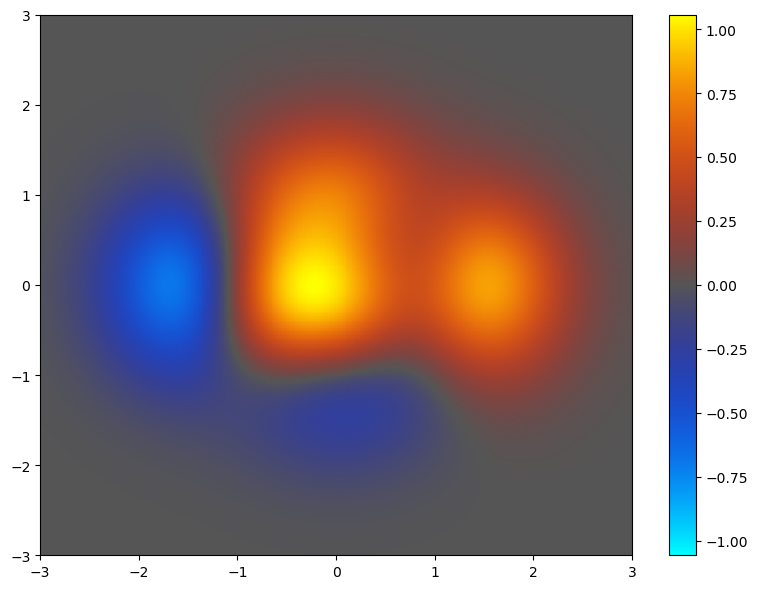

In [ ]:


def ensure_dir(ed):
    import os
    try:
        os.makedirs(ed)
    except OSError:
        if not os.path.isdir(ed):
            raise

def pad_vector(contrast_, n_columns):
    """A small routine to append zeros in contrast vectors"""
    return np.hstack((contrast_, np.zeros(n_columns - len(contrast_))))

def ensure_dir(folder):
    if os.path.isdir(folder) == False:
        os.makedirs(folder)
        
def make_dm_sam(mc, tr):
    z_mc = zscore(mc)
    z_mc.fillna(value=0, inplace=True)
    return Design_Matrix(z_mc, sampling_freq=1/tr)

# Function for loading in confounds files
def load_confounds(confounds_fn):

    # Load the confounds TSV files
    confounds_df = pd.read_csv(confounds_fn, sep='\t')

    # Load the JSON sidecar metadata
    with open(splitext(confounds_fn)[0] + '.json') as f:
        confounds_meta = json.load(f)

    return confounds_df, confounds_meta

import numpy as np
import scipy.interpolate
from matplotlib import cm


def bipolar(lutsize=256, neutral=1/3, interp=None):
    """
    Bipolar hot/cold colormap, with neutral central color.

    This colormap is meant for visualizing diverging data; positive
    and negative deviations from a central value.  It is similar to a "hot"
    blackbody colormap for positive values, but with a complementary
    "cold" colormap for negative values.

    Parameters
    ----------
    lutsize : int
        The number of elements in the colormap lookup table. (Default is 256.)
    neutral : float
        The gray value for the neutral middle of the colormap.  (Default is
        1/3.)
        The colormap goes from cyan-blue-neutral-red-yellow if neutral
        is < 0.5, and from blue-cyan-neutral-yellow-red if `neutral` > 0.5.
        For shaded 3D surfaces, a `neutral` near 0.5 is better, because it
        minimizes luminance changes that would otherwise obscure shading cues
        for determining 3D structure.
        For 2D heat maps, a `neutral` near the 0 or 1 extremes is better, for
        maximizing luminance change and showing details of the data.
    interp : str or int, optional
        Specifies the type of interpolation.
        ('linear', 'nearest', 'zero', 'slinear', 'quadratic, 'cubic')
        or as an integer specifying the order of the spline interpolator
        to use. Default is 'linear' for dark neutral and 'cubic' for light
        neutral.  See `scipy.interpolate.interp1d`.

    Returns
    -------
    out : matplotlib.colors.LinearSegmentedColormap
        The resulting colormap object

    Examples
    --------
    >>> from mpl_toolkits.mplot3d import Axes3D
    >>> import matplotlib.pyplot as plt
    >>> import numpy as np
    >>> from bipolar import bipolar

    >>> x = y = np.arange(-4, 4, 0.15)
    >>> x, y = np.meshgrid(x, y)
    >>> z = (1 - x/2 + x**5 + y**3) * np.exp(-x**2 - y**2)

    >>> fig, axs = plt.subplots(2, 2, figsize=(12, 8),
    ...                         subplot_kw={'projection': '3d'})
    >>> for ax, neutral in (((0, 0), 1/3),  # Default
    ...                     ((0, 1), 0.1),  # Dark gray as neutral
    ...                     ((1, 0), 0.9),  # Light gray as neutral
    ...                     ((1, 1), 2/3),
    ...                     ):
    ...     surf = axs[ax].plot_surface(x, y, z, rstride=1, cstride=1,
    ...                                 vmax=abs(z).max(), vmin=-abs(z).max(),
    ...                                 cmap=bipolar(neutral=neutral))
    >>>     axs[ax].set_title(f'{neutral:.3f}')
    ...     fig.colorbar(surf, ax=axs[ax])
    >>> plt.show()

    References
    ----------
    .. [1] Lehmann Manja, Crutch SJ, Ridgway GR et al. "Cortical thickness
        and voxel-based morphometry in posterior cortical atrophy and typical
        Alzheimer's disease", Neurobiology of Aging, 2009,
        doi:10.1016/j.neurobiolaging.2009.08.017

    """
    n = neutral
    if 0 <= n <= 0.5:
        if interp is None:
            # Seems to work well with dark neutral colors
            interp = 'linear'

        data = (
            (0, 1, 1),  # cyan
            (0, 0, 1),  # blue
            (n, n, n),  # dark neutral
            (1, 0, 0),  # red
            (1, 1, 0),  # yellow
        )
    elif 0.5 < n <= 1:
        if interp is None:
            # Seems to work better with bright neutral colors
            # Produces bright yellow or cyan rings otherwise
            interp = 'cubic'

        data = (
            (0, 0, 1),  # blue
            (0, 1, 1),  # cyan
            (n, n, n),  # light neutral
            (1, 1, 0),  # yellow
            (1, 0, 0),  # red
        )
    else:
        raise ValueError('n must be 0.0 < n < 1.0')

    xi = np.linspace(0, 1, len(data))
    cm_interp = scipy.interpolate.interp1d(xi, data, axis=0, kind=interp)
    xnew = np.linspace(0, 1, lutsize)
    ynew = cm_interp(xnew)

    # Non-linear interpolation exceeds the RGB cube
    ynew = np.clip(ynew, 0, 1)

    return cm.colors.LinearSegmentedColormap.from_list('bipolar', ynew,
                                                       lutsize)


def hotcold(lutsize=256, neutral=1/3, interp=None):
    """
    Bipolar hot/cold colormap, with neutral central color.

    This colormap is meant for visualizing diverging data; positive
    and negative deviations from a central value.  It is similar to a "hot"
    blackbody colormap for positive values, but with a complementary
    "cold" colormap for negative values.

    Parameters
    ----------
    lutsize : int
        The number of elements in the colormap lookup table. (Default is 256.)
    neutral : float
        The gray value for the neutral middle of the colormap.  (Default is
        1/3.)
        The colormap goes from cyan-blue-neutral-red-yellow if neutral
        is < 0.5, and from blue-cyan-neutral-yellow-red if `neutral` > 0.5.
        For shaded 3D surfaces, a `neutral` near 0.5 is better, because it
        minimizes luminance changes that would otherwise obscure shading cues
        for determining 3D structure.
        For 2D heat maps, a `neutral` near the 0 or 1 extremes is better, for
        maximizing luminance change and showing details of the data.
    interp : str or int, optional
        Specifies the type of interpolation.
        ('linear', 'nearest', 'zero', 'slinear', 'quadratic, 'cubic')
        or as an integer specifying the order of the spline interpolator
        to use. Default is 'linear' for dark neutral and 'cubic' for light
        neutral.  See `scipy.interpolate.interp1d`.

    Returns
    -------
    out : matplotlib.colors.LinearSegmentedColormap
        The resulting colormap object

    Examples
    --------
    >>> from mpl_toolkits.mplot3d import Axes3D
    >>> import matplotlib.pyplot as plt
    >>> import numpy as np
    >>> from bipolar import hotcold

    >>> x = y = np.arange(-4, 4, 0.15)
    >>> x, y = np.meshgrid(x, y)
    >>> z = (1 - x/2 + x**5 + y**3) * np.exp(-x**2 - y**2)

    >>> fig, axs = plt.subplots(2, 2, figsize=(12, 8),
    ...                         subplot_kw={'projection': '3d'})
    >>> for ax, neutral in (((0, 0), 1/3),  # Default
    ...                     ((0, 1), 0.1),  # Dark gray as neutral
    ...                     ((1, 0), 0.9),  # Light gray as neutral
    ...                     ((1, 1), 2/3),
    ...                     ):
    ...     surf = axs[ax].plot_surface(x, y, z, rstride=1, cstride=1,
    ...                                 vmax=abs(z).max(), vmin=-abs(z).max(),
    ...                                 cmap=hotcold(neutral=neutral))
    >>>     axs[ax].set_title(f'{neutral:.3f}')
    ...     fig.colorbar(surf, ax=axs[ax])
    >>> plt.show()

    References
    ----------
    .. [1] Lehmann Manja, Crutch SJ, Ridgway GR et al. "Cortical thickness
        and voxel-based morphometry in posterior cortical atrophy and typical
        Alzheimer's disease", Neurobiology of Aging, 2009,
        doi:10.1016/j.neurobiolaging.2009.08.017

    """
    n = neutral
    if 0 <= n <= 0.5:
        if interp is None:
            # Seems to work well with dark neutral colors
            interp = 'linear'

        data = (
            (0, 1, 1),  # cyan
            (0, 0, 1),  # blue
            (n, n, n),  # dark neutral
            (1, 0, 0),  # red
            (1, 1, 0),  # yellow
        )
    elif 0.5 < n <= 1:
        if interp is None:
            # Seems to work better with bright neutral colors
            # Produces bright yellow or cyan rings otherwise
            interp = 'cubic'

        data = (
            (0, 0, 1),  # blue
            (0, 1, 1),  # cyan
            (n, n, n),  # light neutral
            (1, 1, 0),  # yellow
            (1, 0, 0),  # red
        )
    else:
        raise ValueError('n must be 0.0 < n < 1.0')

    t = np.linspace(0, 1, lutsize//2)

    # Super ugly Bezier curve
    # Do 2, one for each half, from nnn to 100 and from 001 to nnn

    x1 = data[2][0]
    y1 = data[2][1]
    z1 = data[2][2]

    xc = data[1][0]
    yc = data[1][1]
    zc = data[1][2]

    x2 = data[0][0]
    y2 = data[0][1]
    z2 = data[0][2]

    w = 1  # weight

    r1 = (((1 - t)**2*x1 + 2*(1 - t)*t*w*xc + t**2*x2) /
          ((1 - t)**2 + 2*(1 - t)*t*w + t**2))
    g1 = (((1 - t)**2*y1 + 2*(1 - t)*t*w*yc + t**2*y2) /
          ((1 - t)**2 + 2*(1 - t)*t*w + t**2))
    b1 = (((1 - t)**2*z1 + 2*(1 - t)*t*w*zc + t**2*z2) /
          ((1 - t)**2 + 2*(1 - t)*t*w + t**2))

    x1 = data[2][0]
    y1 = data[2][1]
    z1 = data[2][2]

    xc = data[3][0]
    yc = data[3][1]
    zc = data[3][2]

    x2 = data[4][0]
    y2 = data[4][1]
    z2 = data[4][2]

    r2 = (((1 - t)**2*x1 + 2*(1 - t)*t*w*xc + t**2*x2) /
          ((1 - t)**2 + 2*(1 - t)*t*w + t**2))
    g2 = (((1 - t)**2*y1 + 2*(1 - t)*t*w*yc + t**2*y2) /
          ((1 - t)**2 + 2*(1 - t)*t*w + t**2))
    b2 = (((1 - t)**2*z1 + 2*(1 - t)*t*w*zc + t**2*z2) /
          ((1 - t)**2 + 2*(1 - t)*t*w + t**2))

    rgb1 = np.dstack((r1, g1, b1))[0]
    rgb2 = np.dstack((r2, g2, b2))[0]

    ynew = np.concatenate((rgb1[1:][::-1], rgb2))

    return cm.colors.LinearSegmentedColormap.from_list('hotcold', ynew,
                                                       lutsize)


if __name__ == "__main__":
    import matplotlib.pyplot as plt

    def func3(x, y):
        return (1 - x/2 + x**5 + y**3) * np.exp(-x**2 - y**2)

    # Make these smaller to increase the resolution
    dx, dy = 0.02, 0.02
    plt.figure(figsize=(8, 6))

    x = np.arange(-3.0, 3.0001, dx)
    y = np.arange(-3.0, 3.0001, dy)
    X, Y = np.meshgrid(x, y)

    Z = func3(X, Y)
    cmap = hotcold(neutral=1/3, interp='linear', lutsize=2048)
    plt.pcolor(X, Y, Z, cmap=cmap, vmax=abs(Z).max(), vmin=-abs(Z).max())
    plt.colorbar()
    plt.axis([-3, 3, -3, 3])
    plt.tight_layout()
    plt.show()
    
from nltools.stats import correlation_permutation
cmap = bipolar(neutral=1/3, interp='linear', lutsize=2048)


### Condition contrasts

R
0.05
Number of participants:114
The p<.05 Bonferroni-corrected threshold is 5.01


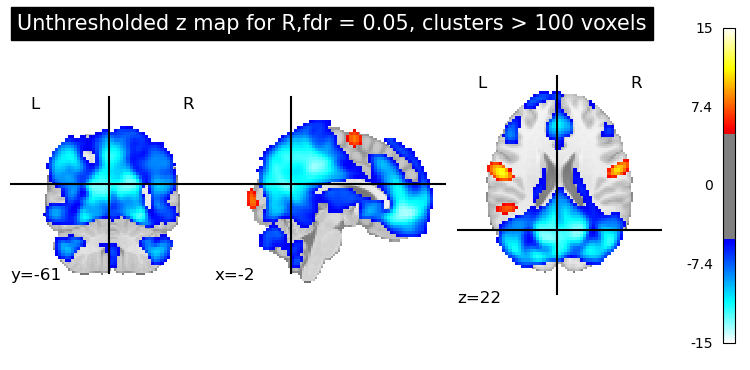

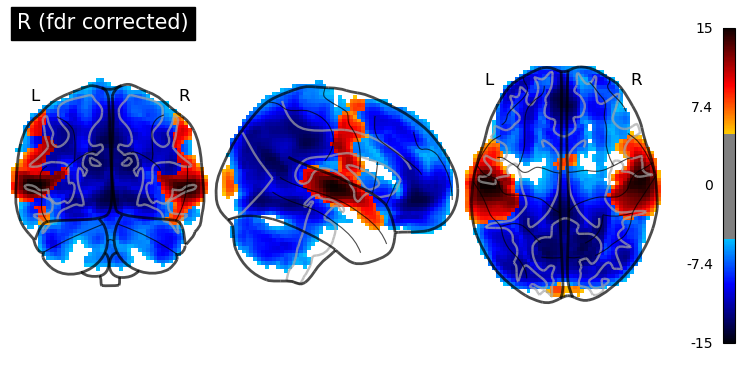

G
0.05
Number of participants:114
The p<.05 Bonferroni-corrected threshold is 5.01


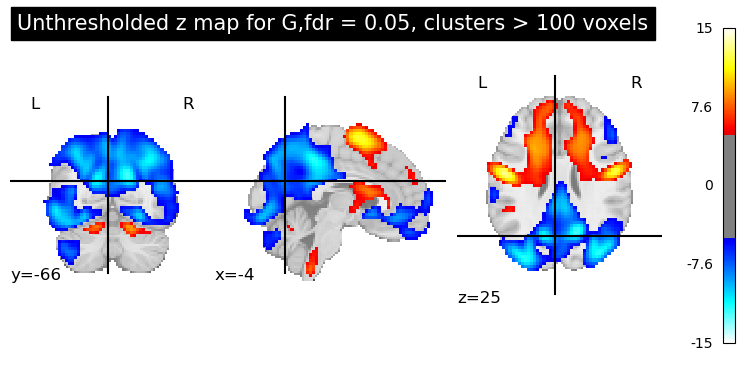

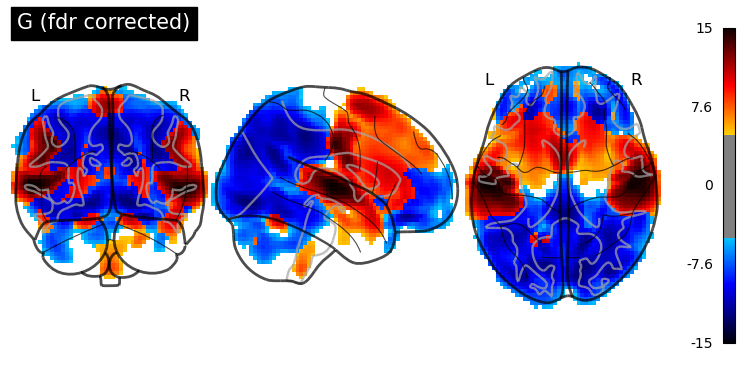

R_vs_G
0.05
Number of participants:114
The p<.05 Bonferroni-corrected threshold is 5.01


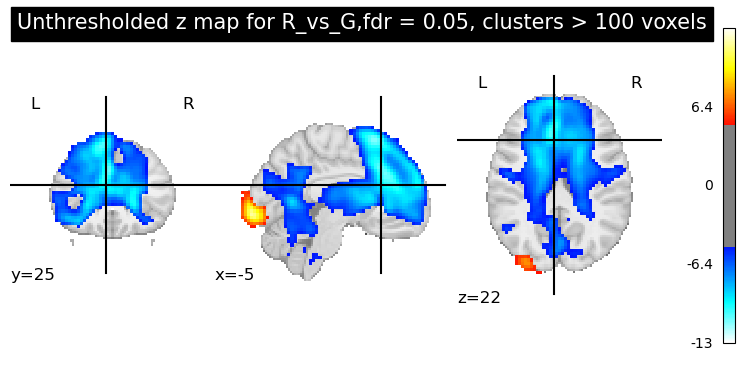

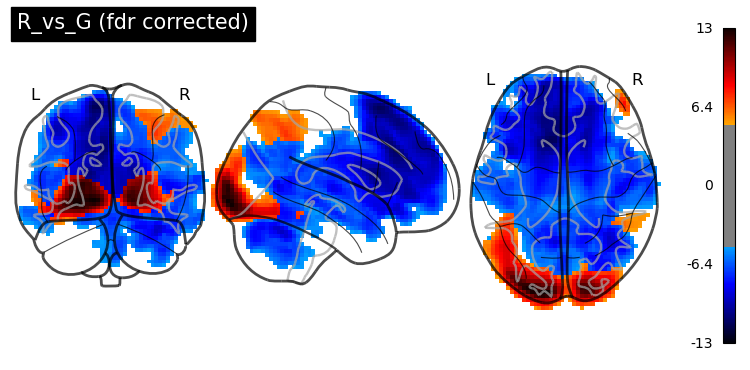

G_vs_R
0.05
Number of participants:114
The p<.05 Bonferroni-corrected threshold is 5.01


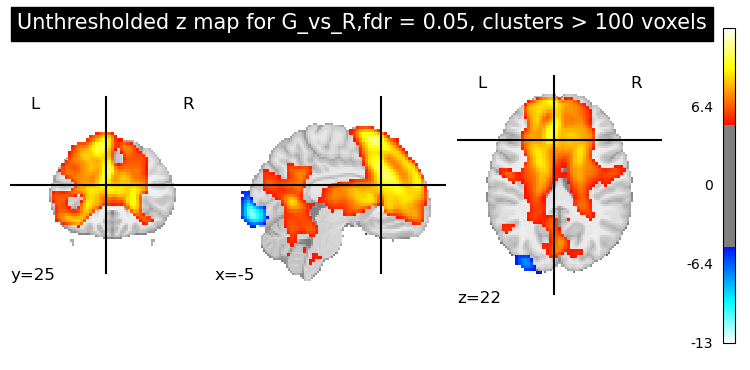

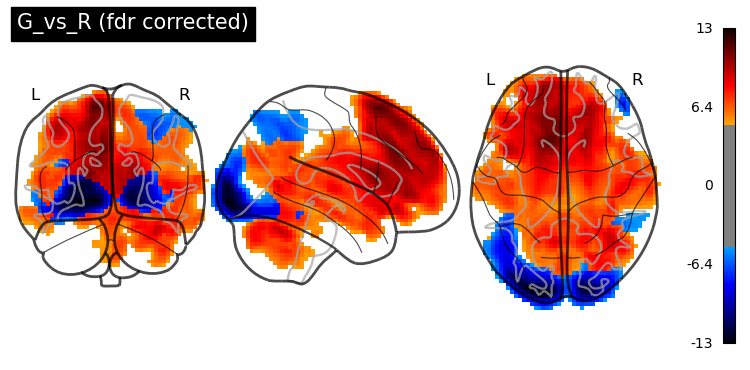

In [ ]:
output_dir= './code/univariate_analysis'
hyp_dir = './data/hyperalignment'
# base_dir='./univariate_analysis/'
# write_dir=opj(base_dir,'Secondlevel','Firstlevel')
# ensure_dir(write_dir)


subs = [i for i in os.listdir(hyp_dir) if i.startswith('sub-')]
subs.sort()
runs = [1,2,3,4,5]
task='CONV'


# firstlevel z map directory define whether balanced or unbalanced
# set output directory
sl_write_dir=opj(output_dir,'Secondlevel')

# get the contrasts
contrasts = ['R', 'G', 'R_vs_G', 'G_vs_R']
model = 'model-9'

for alpha in [0.05]:
    for x in range(len(contrasts)):


        print(contrasts[x])
        print(alpha)

        second_level_input=glob(opj(output_dir,"Firstlevel",contrasts[x],f'*{model}*z_map.nii.gz'))
        print('Number of participants:' + str(len(second_level_input)))

        # specify design matrix
        n_samples=len(second_level_input)
        design_matrix = pd.DataFrame([1] * n_samples, columns=['intercept'])

        # define second level model
        second_level_model = SecondLevelModel(smoothing_fwhm=6, memory_level=1)

        # fit second level model
        second_level_model = second_level_model.fit(second_level_input,
                                                    design_matrix=design_matrix)

        #compute contrast
        z_map = second_level_model.compute_contrast(output_type='z_score')


        # # fdr 0.05 corrected thresholding
        # thresholded_map2, threshold2 = threshold_stats_img(
        #     z_map, alpha=alpha, height_control='fdr', cluster_threshold=50)
        # print('The FDR= %.3g threshold is %.3g' % (alpha, threshold2))

        # fwe 0.05 corrected thresholding
        thresholded_map2, threshold2 = threshold_stats_img(
             z_map, alpha=alpha, height_control="bonferroni",cluster_threshold=100)
        print(f"The p<.05 Bonferroni-corrected threshold is {threshold2:.3g}")


        # plot results 
        plot_stat_map(
            thresholded_map2,  threshold=threshold2,
            title='Unthresholded z map for %s,fdr = %.3g, clusters > 100 voxels' % (contrasts[x], alpha))
        plt.show()
        
        plot_glass_brain(
            thresholded_map2, threshold=threshold2, colorbar=True, plot_abs=False,
            title=f'{contrasts[x]} (fdr corrected)')
        plt.show()

        #write results table
        table = get_clusters_table(thresholded_map2, stat_threshold=threshold2,
                                   cluster_threshold=10)
        ensure_dir(opj(sl_write_dir,task,contrasts[x]))
        table.to_csv(opj(sl_write_dir,task,contrasts[x],  task+'_SecondLevel_result-table1_%s.csv'% contrasts[x])) 

        # write fdr map
        z_image_path = opj(sl_write_dir,task,contrasts[x], 'SecondLevel_results%s_%s_%.3g_z_map.nii.gz' % ( task, contrasts[x], alpha))
        thresholded_map2.to_filename(z_image_path)

/jukebox/tamir/lmt/envs/naturalistic/lib/python3.7/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  UserWarning,
/jukebox/tamir/lmt/envs/naturalistic/lib/python3.7/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  UserWarning,
/jukebox/tamir/lmt/envs/naturalistic/lib/python3.7/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the

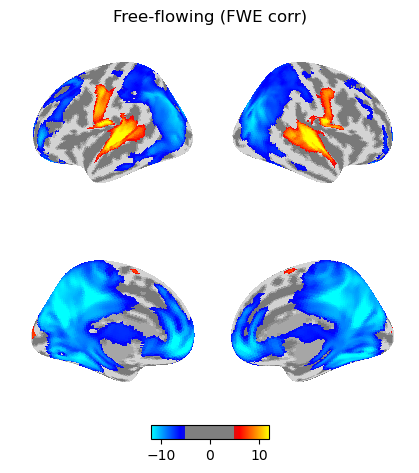

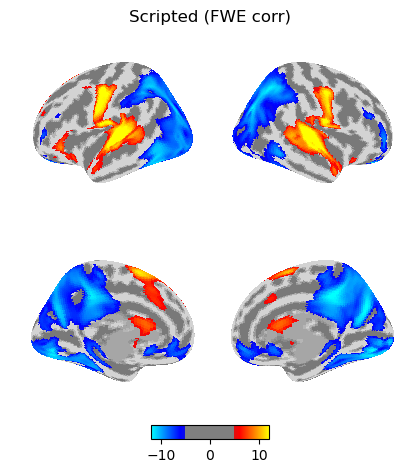

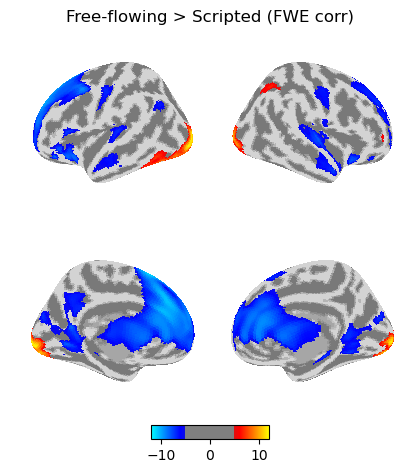

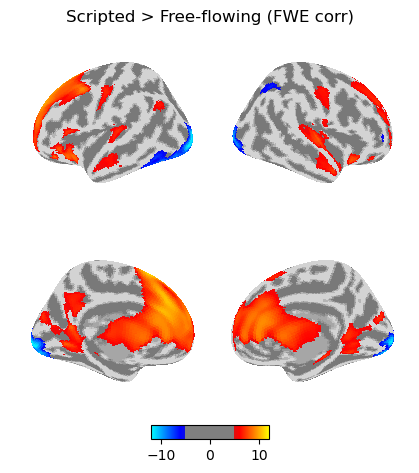

In [ ]:
from nilearn import plotting
#contrasts = ['R', 'G', 'R_vs_G', 'G_vs_R']
contrast_labels = ['Free-flowing', 'Scripted','Free-flowing > Scripted', 'Scripted > Free-flowing']
alpha = "0.05"

for i, c in enumerate(contrasts):
    label = contrast_labels[i]

    z_map = Brain_Data(f"./code/univariate_analysis/Secondlevel/CONV/{c}/SecondLevel_resultsCONV_{c}_{alpha}_z_map.nii.gz")
    plotting.plot_img_on_surf(z_map.to_nifti(),
                          views=['lateral', 'medial'],
                          hemispheres=['left', 'right'],
                          colorbar=True,cmap = cmap,
                          threshold=5.01,vmax = 12,
                          title= f'{label} (FWE corr)',
                          inflate = True,bg_on_data = False)

### FWE Second level results

G
0.05
Number of participants: 114
Computed group mask.


/jukebox/tamir/lmt/envs/naturalistic/lib/python3.7/site-packages/nilearn/glm/_utils.py:346: RuntimeWarning: divide by zero encountered in true_divide
  return np.where(X <= 0, 0, 1.0 / X)


Voxelwise FWE (Bonferroni) threshold at alpha=0.05 is z >= 4.96
Cluster threshold is >= 100 voxels


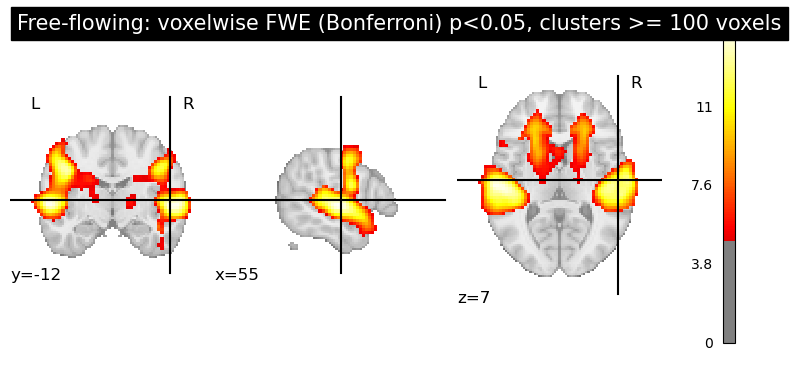

R
0.05
Number of participants: 114
Computed group mask.


/jukebox/tamir/lmt/envs/naturalistic/lib/python3.7/site-packages/nilearn/glm/_utils.py:346: RuntimeWarning: divide by zero encountered in true_divide
  return np.where(X <= 0, 0, 1.0 / X)


Voxelwise FWE (Bonferroni) threshold at alpha=0.05 is z >= 4.95
Cluster threshold is >= 100 voxels


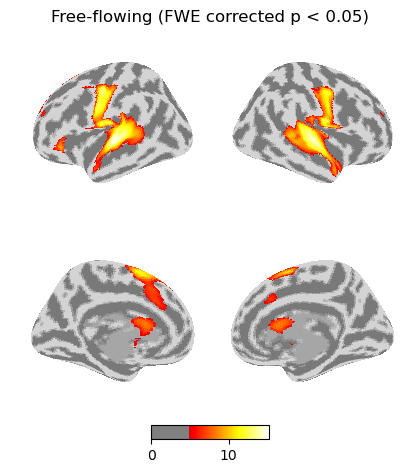

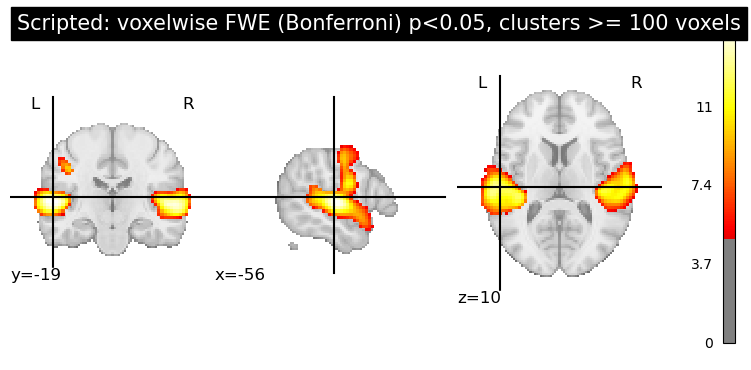

G_vs_R
0.05
Number of participants: 114
Computed group mask.
Voxelwise FWE (Bonferroni) threshold at alpha=0.05 is z >= 4.72
Cluster threshold is >= 100 voxels


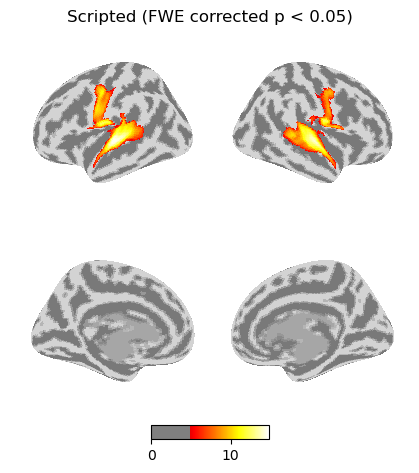

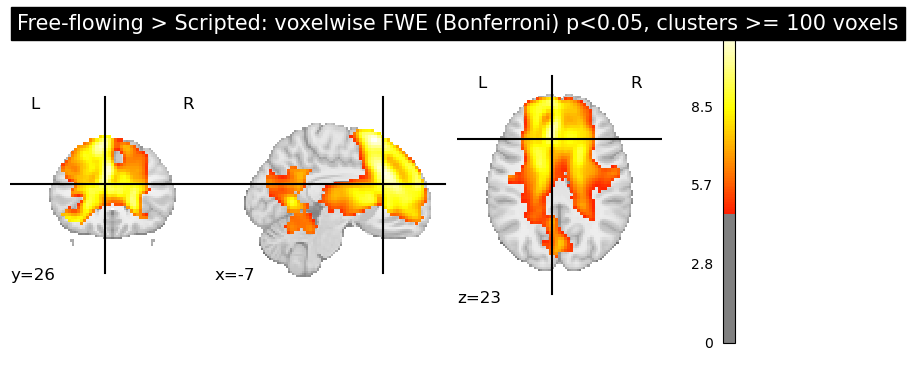

R_vs_G
0.05
Number of participants: 114
Computed group mask.


/jukebox/tamir/lmt/envs/naturalistic/lib/python3.7/site-packages/nilearn/glm/_utils.py:346: RuntimeWarning: divide by zero encountered in true_divide
  return np.where(X <= 0, 0, 1.0 / X)


Voxelwise FWE (Bonferroni) threshold at alpha=0.05 is z >= 4.93
Cluster threshold is >= 100 voxels


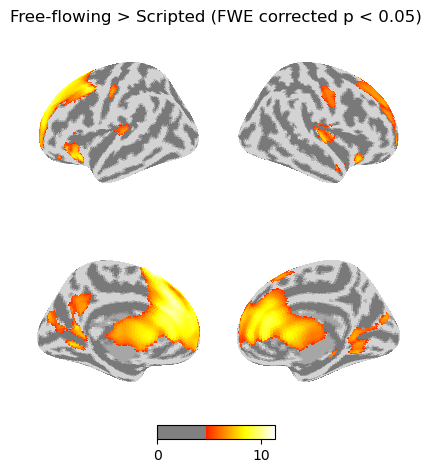

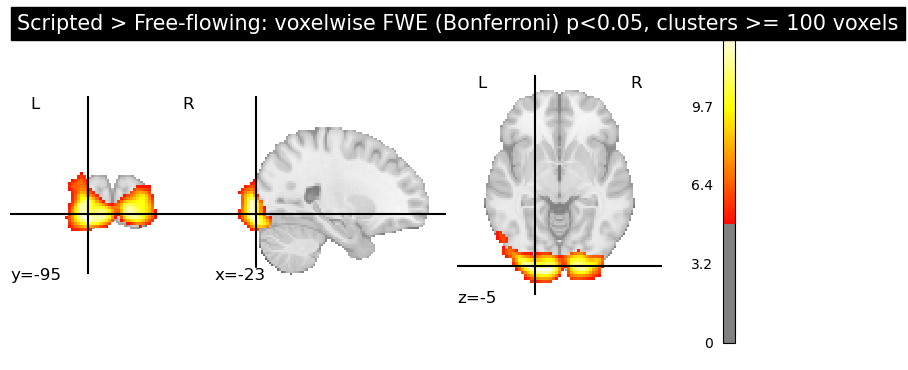

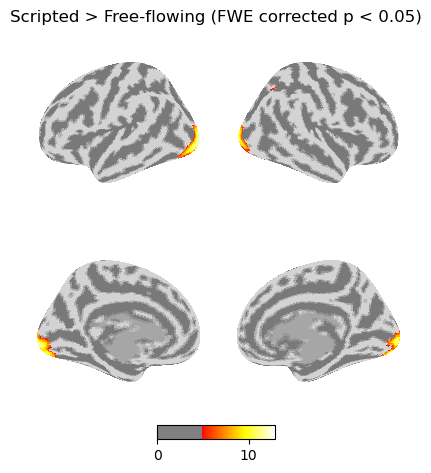

In [ ]:
import os
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img
from nilearn.masking import compute_multi_epi_mask
from nilearn.plotting import plot_stat_map, plot_glass_brain
from nilearn.reporting import get_clusters_table
from nilearn import plotting
from nilearn.image import math_img

output_dir= './code/univariate_analysis'
hyp_dir = './data/hyperalignment'

subs = [i for i in os.listdir(hyp_dir) if i.startswith('sub-')]
subs.sort()

runs = [1, 2, 3, 4, 5]
task = "CONV"

sl_write_dir = opj(output_dir, "Secondlevel")

contrasts = ['G', 'R', 'G_vs_R', 'R_vs_G']
contrast_labels = ['Free-flowing', 'Scripted','Free-flowing > Scripted', 'Scripted > Free-flowing']
model = "model-9"

alpha = 0.05
cluster_threshold = 100
smoothing_fwhm = 6

for i, con in enumerate(contrasts):
    print(con)
    print(alpha)
    label = contrast_labels[i]


    second_level_input = glob(opj(output_dir, "Firstlevel", con, f"*{model}*z_map.nii.gz"))
    second_level_input.sort()
    print("Number of participants: " + str(len(second_level_input)))

    n_samples = len(second_level_input)
    design_matrix = pd.DataFrame({"intercept": [1] * n_samples})

    # Group mask from your subject maps (assumes all are aligned in the same space)
    group_mask = compute_multi_epi_mask(second_level_input)
    print("Computed group mask.")

    # Second level model with explicit mask
    second_level_model = SecondLevelModel(
        smoothing_fwhm=smoothing_fwhm,
        mask_img=group_mask,
        memory_level=1
    ).fit(second_level_input, design_matrix=design_matrix)

    z_map = second_level_model.compute_contrast(output_type="z_score")

    # Voxelwise FWE control (Bonferroni)
    thresholded_map2, threshold2 = threshold_stats_img(
        z_map,
        alpha=alpha,
        height_control="bonferroni",
        cluster_threshold=cluster_threshold,
        two_sided= True
    )
    print(f"Voxelwise FWE (Bonferroni) threshold at alpha={alpha} is z >= {threshold2:.3g}")
    print(f"Cluster threshold is >= {cluster_threshold} voxels")

    # Plots
    plot_stat_map(
        thresholded_map2,
        threshold=threshold2,
        title=f"{label}: voxelwise FWE (Bonferroni) p<{alpha}, clusters >= {cluster_threshold} voxels"
    )
    plt.show()

    # surface
    plotting.plot_img_on_surf(
        thresholded_map2,
        views=['lateral', 'medial'],
        hemispheres=['left', 'right'],
        colorbar=True,
        cmap="hot",
        threshold=threshold2,
        title=f'{label} (FWE corrected p < 0.05)',
        inflate=True,
        bg_on_data=False)

    # plot_glass_brain(
    #     thresholded_map2,
    #     threshold=threshold2,
    #     colorbar=True,
    #     plot_abs=False,
    #     title=f"{con}: voxelwise FWE (Bonferroni)"
    # )
    # plt.show()

    # Results table (match cluster threshold)
    table = get_clusters_table(
        thresholded_map2,
        stat_threshold=threshold2,
        cluster_threshold=cluster_threshold
    )

    ensure_dir(opj(sl_write_dir, task, con))
    table.to_csv(
        opj(sl_write_dir, task, con, f"{task}_SecondLevel_result-table1_{con}.csv"),
        index=False
    )

    # Write thresholded map
    z_image_path = opj(
        sl_write_dir, task, con,
        f"SecondLevel_FWEbonf_p{alpha:.3g}_{task}_{con}_z_map.nii.gz"
    )
    thresholded_map2.to_filename(z_image_path)

/jukebox/tamir/lmt/envs/naturalistic/lib/python3.7/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  UserWarning,
/jukebox/tamir/lmt/envs/naturalistic/lib/python3.7/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  UserWarning,
/jukebox/tamir/lmt/envs/naturalistic/lib/python3.7/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the

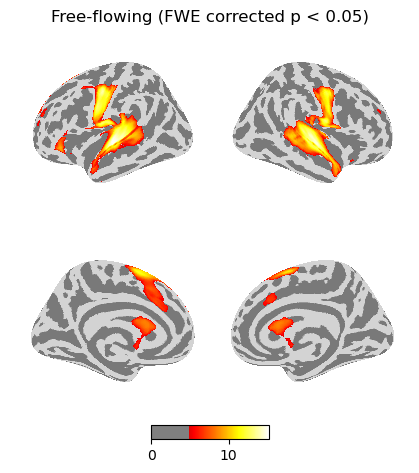

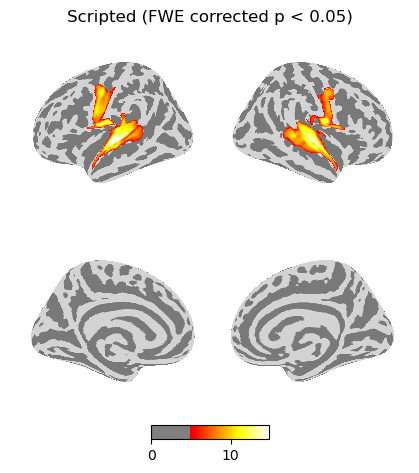

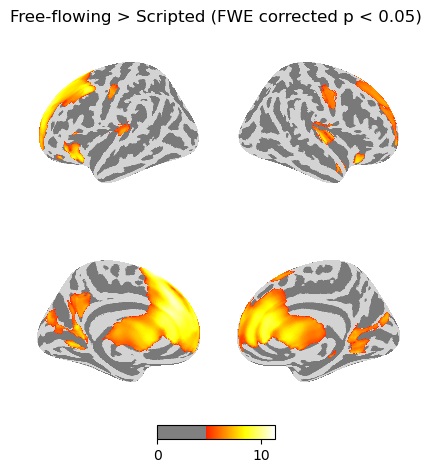

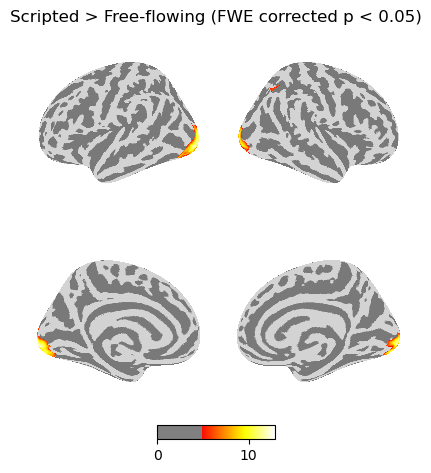

In [ ]:
from nilearn import plotting
from nilearn.image import math_img

contrasts = ['G', 'R', 'G_vs_R', 'R_vs_G']
contrast_labels = ['Free-flowing', 'Scripted','Free-flowing > Scripted', 'Scripted > Free-flowing']
thresholds = [4.96,4.95,4.72,4.93]
alpha = "0.05"

for i, c in enumerate(contrasts):
    label = contrast_labels[i]
    thr = thresholds[i]

    z_map = Brain_Data(f"./code/univariate_analysis/Secondlevel/CONV/{c}/SecondLevel_FWEbonf_p{alpha}_CONV_{c}_z_map.nii.gz")

    #plot
    plotting.plot_img_on_surf(
        z_map.to_nifti(),
        surf_mesh='fsaverage',
        views=['lateral', 'medial'],
        hemispheres=['left', 'right'],
        colorbar=True,
        cmap="hot",
        threshold=thr,
        title=f'{label} (FWE corrected p < 0.05)',
        inflate=True,
        bg_on_data=False)

### Group contrast
This isn't included in this manuscript so removing script. Original script has full model.
